# marv-vision · Qwen3-VL-2B on Colab

**Two jobs at once:** learn how a vision transformer actually works, and do step 1
of [marv-vision](https://github.com/thebnbrkr/marv-vision) — confirm the real module
names and count the dead features in the vision tower.

Model: `Qwen/Qwen3-VL-2B-Instruct` — the backbone of **nuVLA**, the planning baseline
for the nuReasoning driving benchmark.

**Runtime → Change runtime type → L4 GPU.** An L4 (compute 8.9) has bfloat16.
A T4 (7.5) does not, and the cells below pick the dtype for you either way.
A TPU will not work well here: PyTorch/XLA fights forward hooks and dynamic image shapes.

> This notebook has **not been run end to end** yet. That is the point — it is the
> bridge from what `config.json` says to what the loaded model actually contains.

## 0 · Setup

In [1]:
!pip -q install "transformers>=4.57.0" accelerate pillow
!git clone -q https://github.com/thebnbrkr/marv-vision.git 2>/dev/null || echo "already cloned"
%cd /content/marv-vision

import transformers, torch
print("transformers", transformers.__version__, "| torch", torch.__version__, "| cuda", torch.version.cuda)
assert tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 57), \
    f"need transformers >= 4.57 for Qwen3-VL, got {transformers.__version__}"


/content/marv-vision
transformers 5.17.0 | torch 2.11.0+cu130 | cuda 13.0


In [2]:
import torch, sys

if not torch.cuda.is_available():
    raise SystemExit("No GPU. Runtime -> Change runtime type -> L4 GPU.")

name = torch.cuda.get_device_name(0)
major, minor = torch.cuda.get_device_capability()
HAS_BF16 = major >= 8
DTYPE = torch.bfloat16 if HAS_BF16 else torch.float16

print(f"GPU        : {name}  (compute {major}.{minor})")
print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"bfloat16   : {HAS_BF16}")
print(f"-> using   : {DTYPE}")
if not HAS_BF16:
    print("\n   T4 detected. The checkpoint is bf16 but this GPU has none, so we load")
    print("   fp16 instead. Passing dtype='auto' here is the trap that cost marv-hyena a round.")

GPU        : NVIDIA L4  (compute 8.9)
VRAM       : 23.7 GB
bfloat16   : True
-> using   : torch.bfloat16


## 0b · Colab environment fix (run this — it is not optional)

Colab currently ships a broken NVRTC setup: PyTorch JIT-compiles some reduction kernels
at runtime, and NVRTC cannot find `libnvrtc-builtins.so.13.0` even though pip installed
it. Any CUDA `.prod()` blows up with a wall of generated C++ — and Qwen3-VL's
`get_image_features` calls exactly that.

Known Colab bug: [googlecolab/colabtools#6111](https://github.com/googlecolab/colabtools/issues/6111).

*marv-hyena round 0, same lesson: a fresh cloud image is a moving target. Pin versions,
assert them, fail loudly.*

In [3]:
import glob, os, subprocess

builtins = sorted(glob.glob("/usr/local/lib/python3*/dist-packages/nvidia/**/libnvrtc-builtins.so*", recursive=True))
nvrtc    = sorted(glob.glob("/usr/local/lib/python3*/dist-packages/nvidia/**/libnvrtc.so*", recursive=True))
print("builtins found:", builtins or "NONE")
print("libnvrtc found:", nvrtc or "NONE")

linked = []
if builtins:
    src  = builtins[0]
    base = os.path.basename(src)
    dirs = ["/usr/lib/x86_64-linux-gnu", "/usr/local/cuda/lib64", "/usr/local/lib"]
    if nvrtc:
        dirs.insert(0, os.path.dirname(nvrtc[0]))     # NVRTC looks beside itself first
    for d in dirs:
        if not os.path.isdir(d):
            continue
        dst = os.path.join(d, base)
        if os.path.exists(dst):
            continue
        try:
            os.symlink(src, dst); linked.append(dst)
        except OSError as e:
            print("  skip", dst, e)
    subprocess.run(["ldconfig"], check=False)
    os.environ["LD_LIBRARY_PATH"] = os.path.dirname(src) + ":" + os.environ.get("LD_LIBRARY_PATH", "")

print("symlinked ->", linked or "nothing new")

builtins found: ['/usr/local/lib/python3.13/dist-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0', '/usr/local/lib/python3.13/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc-builtins.so.12.9']
libnvrtc found: ['/usr/local/lib/python3.13/dist-packages/nvidia/cu13/lib/libnvrtc.so.13', '/usr/local/lib/python3.13/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc.so.12']
symlinked -> ['/usr/lib/x86_64-linux-gnu/libnvrtc-builtins.so.13.0', '/usr/local/cuda/lib64/libnvrtc-builtins.so.13.0', '/usr/local/lib/libnvrtc-builtins.so.13.0']


In [4]:
# THE test. This is the exact op that fails inside get_image_features.
import torch

try:
    g = torch.tensor([[1, 32, 46]], device="cuda")
    print("cuda prod OK:", g.prod(-1).tolist())
    NVRTC_OK = True
except RuntimeError as e:
    NVRTC_OK = False
    print("still broken:", str(e).strip().splitlines()[-1])
    print("\n-> run the FALLBACK cell below, then carry on.")

cuda prod OK: [1472]


### Fallback, only if the cell above still fails

Two options, cheapest first.

**A. Restart and rerun.** `Runtime -> Restart session`, then run from the top. The symlinks
survive the restart and NVRTC re-reads the loader path on a fresh process. This fixes it
most of the time.

**B. Keep the tiny tensor on CPU.** The failing op is a 3-element `int64` product whose
result is immediately `.tolist()`-ed, so nothing is lost by computing it on the CPU. The
cell below patches just that, and leaves every other tensor on the GPU.

In [5]:
# FALLBACK B -- only run this if the cuda prod test above failed.
if not NVRTC_OK:
    _real_prod = torch.Tensor.prod

    def _cpu_prod(self, *a, **k):
        # route only the tiny int64 grid reductions through the CPU; everything
        # else keeps its normal (precompiled) GPU kernel
        if self.is_cuda and self.dtype in (torch.int32, torch.int64) and self.numel() <= 64:
            return _real_prod(self.cpu(), *a, **k).to(self.device)
        return _real_prod(self, *a, **k)

    torch.Tensor.prod = _cpu_prod
    print("patched torch.Tensor.prod for small integer CUDA tensors")
    print("check:", torch.tensor([[1, 32, 46]], device="cuda").prod(-1).tolist())
else:
    print("not needed -- NVRTC is working")

not needed -- NVRTC is working


## 1 · The shapes, before downloading anything

`config.json` alone tells you the whole structure. Run this first — it costs nothing
and it is the ground truth everything else is checked against.

In [6]:
!python scripts/inspect_model.py --no-load

config.json: 100% 1.50k/1.50k [00:00<00:00, 3.38MB/s]

Qwen/Qwen3-VL-2B-Instruct

  text     28 layers  hidden 2048  inter 6144  silu               gated       172,032 features
  vision   24 layers  hidden 1024  inter 4096  gelu_pytorch_tanh  NOT gated    98,304 features
  total                                                                          270,336 features

  DeepStack taps vision layers: 5 (21%), 11 (46%), 17 (71%) of 24
  tie_word_embeddings=True -> lm_head IS embed; do not store two copies



### What you just saw

| | vision tower | text tower |
|---|---|---|
| layers | 24 | 28 |
| hidden | 1024 | 2048 |
| intermediate | 4096 | 6144 |
| activation | `gelu_pytorch_tanh` | `silu` |
| FFN form | `fc1 -> GELU -> fc2` (**not gated**) | `gate/up/down_proj` (**gated**) |
| features | **98,304** | **172,032** |

**270,336 FFN features** — few enough to enumerate every one. That is MARV's whole bet,
and it survives at 2B.

`deepstack_visual_indexes: [5, 11, 17]` means the model pulls features out of vision
layers 5, 11 and 17 (of 24) and injects them into the language model's early layers.
The architecture is telling you the best visual features are **not at the output** —
which is exactly the [Perception Encoder](https://arxiv.org/abs/2504.13181) finding,
hard-wired.

## 2 · Load the model

In [7]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

MODEL = "Qwen/Qwen3-VL-2B-Instruct"
model = Qwen3VLForConditionalGeneration.from_pretrained(MODEL, dtype=DTYPE, device_map="cuda")
model.eval()
proc = AutoProcessor.from_pretrained(MODEL)

n = sum(p.numel() for p in model.parameters())
print(f"{n/1e9:.2f}B params, {torch.cuda.memory_allocated()/1e9:.1f} GB on GPU")

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.26GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

2.13B params, 4.3 GB on GPU


## 3 · Step 1 of the project: what are the modules *actually* called?

`marv_vision/arch.py` knows the FFN **form** from the config. It does **not** know the
attribute **spellings** — those have to be read off a loaded model. This is the cell the
whole repo is currently blocked on.

In [8]:
from marv_vision.arch import describe_model

paths = describe_model(model)
paths

text layers   : model.language_model.layers  (28 layers)
vision blocks : model.visual.blocks  (24 blocks)

text  mlp type: Qwen3VLTextMLP
      attrs   : ['down_proj', 'gate_proj', 'up_proj']
      gated (gate_proj/up_proj/down_proj) present: True

vision mlp type: Qwen3VLVisionMLP
       attrs   : ['linear_fc1', 'linear_fc2']
       resolved: ('linear_fc1', 'linear_fc2')


{'text_layers_path': 'model.language_model.layers',
 'vision_blocks_path': 'model.visual.blocks',
 'text_mlp_attrs': ('gate_proj', 'up_proj', 'down_proj'),
 'vision_mlp_attrs': ('linear_fc1', 'linear_fc2')}

In [9]:
# The full tree, if the above left anything ambiguous.
# Long -- skim the two `mlp` entries, that is what matters.
print(model)

Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1024)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
 

**Paste the output of the two cells above back into the chat** and the `VisionTowerFFN`
adapter can be written against real names instead of guesses.

## 4 · What is a "patch"? (the core idea, if you're new to vision)

A text transformer turns a sentence into tokens by looking words up in a table.
A vision transformer turns an image into tokens by **cutting it into squares**
and linearly projecting the raw pixels of each square.

That is the only difference at the input. Everything after it — attention, MLP,
residual stream — is the transformer you already know.

image size: (960, 686)


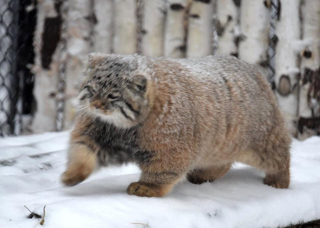

In [10]:
from PIL import Image
import requests, math

URL = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
img = Image.open(requests.get(URL, stream=True).raw).convert("RGB")
print("image size:", img.size)
img.resize((320, int(320*img.size[1]/img.size[0])))

In [11]:
msgs = [{"role": "user", "content": [
    {"type": "image", "image": URL},
    {"type": "text",  "text": "Describe this image."}]}]

inputs = proc.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True,
                                 return_dict=True, return_tensors="pt").to(model.device)

cfg  = model.config.vision_config
px   = inputs["pixel_values"]
n_img_tok = int((inputs["input_ids"][0] == model.config.image_token_id).sum())

print(f"pixel_values shape : {tuple(px.shape)}")
print(f"patch size         : {cfg.patch_size}x{cfg.patch_size} pixels")
print(f"spatial_merge_size : {cfg.spatial_merge_size}  (2x2 patches merged into 1 token)")
print(f"total sequence     : {inputs['input_ids'].shape[1]} tokens")
print(f"  of which VISUAL  : {n_img_tok}")
print(f"  of which text    : {inputs['input_ids'].shape[1] - n_img_tok}")

pixel_values shape : (2520, 1536)
patch size         : 16x16 pixels
spatial_merge_size : 2  (2x2 patches merged into 1 token)
total sequence     : 644 tokens
  of which VISUAL  : 630
  of which text    : 14


Note how many of the tokens are visual. **This is where your memory goes** — not the
weights. The model is ~4 GB; a 20-second multi-camera driving clip is thousands of
visual tokens and is what will OOM a T4.

## 5 · Run it

In [12]:
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=64, do_sample=False)
trimmed = out[0][inputs["input_ids"].shape[1]:]
print(proc.decode(trimmed, skip_special_tokens=True))

This image captures a **Pallas's cat** (*Otocolobus manul*) in a snowy, winter environment. The animal is the central focus, shown in motion as it walks across a snow-covered ground.

Here is a detailed description of the image:

- **The Animal**: The Pallas's cat is


## 6 · The two FFN forms, side by side

This is the structural difference that forces a new adapter. Look at the shapes.

In [13]:
tl = model.model.language_model.layers if hasattr(model.model, "language_model") else model.model.layers
vb = model.model.visual.blocks

print("TEXT tower MLP (gated -- three matrices):")
for nme, p in tl[0].mlp.named_parameters():
    print(f"   {nme:<20} {tuple(p.shape)}")

print("\nVISION tower MLP (not gated -- two matrices):")
for nme, p in vb[0].mlp.named_parameters():
    print(f"   {nme:<20} {tuple(p.shape)}")

TEXT tower MLP (gated -- three matrices):
   gate_proj.weight     (6144, 2048)
   up_proj.weight       (6144, 2048)
   down_proj.weight     (2048, 6144)

VISION tower MLP (not gated -- two matrices):
   linear_fc1.weight    (4096, 1024)
   linear_fc1.bias      (4096,)
   linear_fc2.weight    (1024, 4096)
   linear_fc2.bias      (1024,)


**Text:** `gate_proj` and `up_proj` both read the input; `gate_proj` is a pure
*detector bank*, which is why MARV can ask "which features respond to this direction?"
and get a clean answer.

**Vision:** one matrix (`fc1`-ish) does detection and magnitude at once. The same
question is blurrier here. That is a property of the architecture, not a bug.

GELU vs SiLU, by the way, is a **footnote** — both are smooth pointwise curves and
nothing in extraction, diff, suppression or ablation cares which. *Gated vs not* is the
real difference.

## 7 · First real experiment: how much of the vision tower is dead?

In marv-hyena you found **724 of Evo 2's first-layer channels (18%) never fire**, and
that a previous round's headline finding had been built on one of them. A dead neuron's
"top activating images" are always nine confident-looking pictures of nothing.

So: before labelling any feature, count the dead ones. Nobody has published this number
for Qwen3-VL's vision tower.

In [14]:
IMAGES = [
 "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg",
 "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png",
 "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/bee.jpg",
 "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg",
]
print(f"{len(IMAGES)} images -- PRELIMINARY only.")
print("A number worth reporting needs hundreds of diverse images. Extend this list.")

4 images -- PRELIMINARY only.
A number worth reporting needs hundreds of diverse images. Extend this list.


In [15]:
import torch

VIS = model.model.visual.blocks
D   = model.config.vision_config.intermediate_size
L   = len(VIS)

# Peak |activation| per (layer, feature), over every image AND every patch.
peak = torch.zeros(L, D, device=model.device, dtype=torch.float32)
handles = []

def mk(li):
    # fires on the SECOND matrix's input == the post-activation values
    def hook(mod, args):
        a = args[0].detach().float().abs()          # (..., intermediate)
        peak[li] = torch.maximum(peak[li], a.reshape(-1, a.shape[-1]).amax(0))
    return hook

# second matrix of the vision MLP, whatever it is called
second = [n for n, _ in VIS[0].mlp.named_children()][-1]
print(f"hooking vision mlp.{second} (the second matrix)")

try:
    for li, blk in enumerate(VIS):
        handles.append(getattr(blk.mlp, second).register_forward_pre_hook(mk(li)))

    for u in IMAGES:
        m = [{"role": "user", "content": [{"type": "image", "image": u},
                                          {"type": "text", "text": "Describe this."}]}]
        inp = proc.apply_chat_template(m, tokenize=True, add_generation_prompt=True,
                                       return_dict=True, return_tensors="pt").to(model.device)
        with torch.no_grad():
            model(**inp)
        print(".", end="")
finally:
    for h in handles:
        h.remove()                 # hooks are ALWAYS removed, even on exception
print(" done")

hooking vision mlp.act_fn (the second matrix)
.... done


In [16]:
TOL = 1e-6
dead = (peak < TOL)

print(f"vision tower: {L} layers x {D} features = {L*D:,}")
print(f"dead (peak |act| < {TOL}) : {int(dead.sum()):,}  ({dead.float().mean():.1%})\n")
print(" layer   dead   %")
for li in range(L):
    d = int(dead[li].sum())
    bar = "#" * int(40 * d / D)
    print(f"  L{li:<3}  {d:>5}  {d/D:>5.1%}  {bar}")

vision tower: 24 layers x 4096 features = 98,304
dead (peak |act| < 1e-06) : 0  (0.0%)

 layer   dead   %
  L0        0   0.0%  
  L1        0   0.0%  
  L2        0   0.0%  
  L3        0   0.0%  
  L4        0   0.0%  
  L5        0   0.0%  
  L6        0   0.0%  
  L7        0   0.0%  
  L8        0   0.0%  
  L9        0   0.0%  
  L10       0   0.0%  
  L11       0   0.0%  
  L12       0   0.0%  
  L13       0   0.0%  
  L14       0   0.0%  
  L15       0   0.0%  
  L16       0   0.0%  
  L17       0   0.0%  
  L18       0   0.0%  
  L19       0   0.0%  
  L20       0   0.0%  
  L21       0   0.0%  
  L22       0   0.0%  
  L23       0   0.0%  


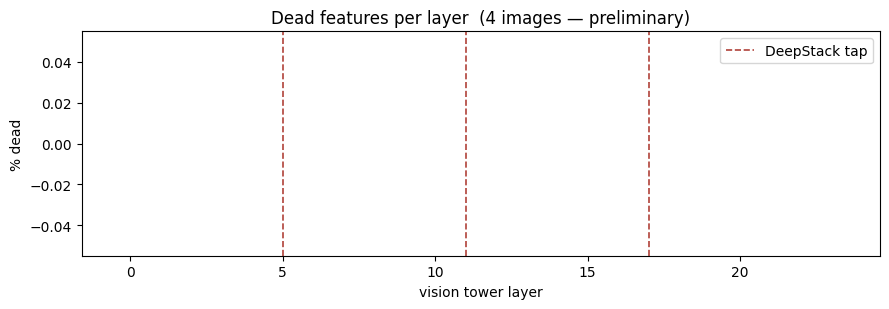

In [17]:
import matplotlib.pyplot as plt

ds = model.config.vision_config.deepstack_visual_indexes
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(range(L), (dead.float().mean(1) * 100).cpu(), color="#3A8455")
for i, t in enumerate(ds):
    ax.axvline(t, color="#B0423A", ls="--", lw=1.2,
               label="DeepStack tap" if i == 0 else None)
ax.set_xlabel("vision tower layer"); ax.set_ylabel("% dead")
ax.set_title(f"Dead features per layer  ({len(IMAGES)} images — preliminary)")
ax.legend(); plt.tight_layout(); plt.show()

### Reading this honestly

- With a handful of images this is an **upper bound on "alive"**, not a dead-feature
  count. A neuron that fires only on traffic cones looks dead if you never show it one.
- The number only becomes reportable with hundreds of diverse images — and, for the
  driving claim, with driving images.
- **This is the precondition, not the result.** Any later "feature X detects
  pedestrians" claim is worthless if X is in this set.

Do the DeepStack taps (red lines) sit in unusually live parts of the tower? That is a
free question this plot can already start to answer.

## Next

1. Paste the section-3 output back into the chat → `VisionTowerFFN` gets written.
2. Confirm MARV's existing `LlamaStyleFFN` picks up the **text** tower unchanged —
   that validates half the port with zero new code.
3. Extend `IMAGES` to a few hundred and rerun section 7 for a real number.
4. Then, and only then, feature labelling — against an answer key (3D boxes, HD map),
   never by eyeballing.